<a href="https://colab.research.google.com/github/1ZeroStorm/Hydrocarbon-with-Machine-Learning/blob/main/Hydrocarbon_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# 1. IMPORT LIBRARY YANG DIBUTUHKAN
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
# ============================================
# 2. LOAD DATA DARI STRING CSV
# ============================================

csv_data = '''No,Rumus,n_C,n_H,Berat Molekul,Jenis Rantai,Titik Didih (°C),Fraksi
1,CH₄,1,4,16.04,Lurus,-161.5,Gas
2,C₂H₆,2,6,30.07,Lurus,-88.6,Gas
3,C₃H₈,3,8,44.10,Lurus,-42.1,Gas
4,C₄H₁₀,4,10,58.12,Lurus,-0.5,Gas
5,C₄H₁₀,4,10,58.12,Bercabang,-11.7,Gas
6,C₅H₁₂,5,12,72.15,Lurus,36.1,Bensin
7,C₅H₁₂,5,12,72.15,Bercabang,27.8,Bensin
8,C₅H₁₂,5,12,72.15,Bercabang,9.5,Bensin
9,C₆H₁₄,6,14,86.18,Lurus,68.7,Bensin
10,C₆H₁₄,6,14,86.18,Bercabang,60.3,Bensin
11,C₆H₁₄,6,14,86.18,Bercabang,63.3,Bensin
12,C₆H₁₄,6,14,86.18,Bercabang,49.7,Bensin
13,C₆H₁₄,6,14,86.18,Bercabang,58.0,Bensin
14,C₇H₁₆,7,16,100.20,Lurus,98.4,Bensin
15,C₇H₁₆,7,16,100.20,Bercabang,90.1,Bensin
16,C₇H₁₆,7,16,100.20,Bercabang,91.9,Bensin
17,C₇H₁₆,7,16,100.20,Bercabang,93.5,Bensin
18,C₇H₁₆,7,16,100.20,Bercabang,79.2,Bensin
19,C₇H₁₆,7,16,100.20,Bercabang,89.8,Bensin
20,C₇H₁₆,7,16,100.20,Bercabang,80.5,Bensin
21,C₇H₁₆,7,16,100.20,Bercabang,86.1,Bensin
22,C₇H₁₆,7,16,100.20,Bercabang,80.9,Bensin
23,C₈H₁₈,8,18,114.23,Lurus,125.7,Bensin
24,C₈H₁₈,8,18,114.23,Bercabang,117.7,Bensin
25,C₈H₁₈,8,18,114.23,Bercabang,118.9,Bensin
26,C₈H₁₈,8,18,114.23,Bercabang,117.7,Bensin
27,C₈H₁₈,8,18,114.23,Bercabang,106.8,Bensin
28,C₈H₁₈,8,18,114.23,Bercabang,115.6,Bensin
29,C₈H₁₈,8,18,114.23,Bercabang,109.4,Bensin
30,C₈H₁₈,8,18,114.23,Bercabang,109.1,Bensin
31,C₈H₁₈,8,18,114.23,Bercabang,112.0,Bensin
32,C₈H₁₈,8,18,114.23,Bercabang,117.7,Bensin
33,C₈H₁₈,8,18,114.23,Bercabang,118.5,Bensin
34,C₈H₁₈,8,18,114.23,Bercabang,109.8,Bensin
35,C₈H₁₈,8,18,114.23,Bercabang,99.2,Bensin
36,C₈H₁₈,8,18,114.23,Bercabang,114.8,Bensin
37,C₈H₁₈,8,18,114.23,Bercabang,113.5,Bensin
38,C₉H₂₀,9,20,128.26,Lurus,150.8,Minyak Tanah / Diesel
39,C₁₀H₂₂,10,22,142.28,Lurus,174.1,Minyak Tanah / Diesel
40,C₁₁H₂₄,11,24,156.31,Lurus,195.9,Minyak Tanah / Diesel
41,C₁₂H₂₆,12,26,170.33,Lurus,216.3,Minyak Tanah / Diesel
42,C₅H₁₀,5,10,70.13,Siklik,49.3,Bensin
43,C₆H₁₂,6,12,84.16,Siklik,71.8,Bensin
44,C₆H₁₂,6,12,84.16,Siklik,80.7,Bensin
45,C₇H₁₄,7,14,98.19,Siklik,101.1,Bensin
46,C₁₃H₂₈,13,28,184.36,Lurus,235.4,Minyak Tanah / Diesel
47,C₁₄H₃₀,14,30,198.39,Lurus,253.6,Minyak Tanah / Diesel
48,C₁₅H₃₂,15,32,212.42,Lurus,270.6,Minyak Tanah / Diesel
49,C₁₆H₃₄,16,34,226.44,Lurus,286.8,Minyak Tanah / Diesel
50,C₁₇H₃₆,17,36,240.47,Lurus,302.6,Minyak Tanah / Diesel
51,C₁₈H₃₈,18,38,254.50,Lurus,317.4,Minyak Berat / Pelumas
52,C₁₉H₄₀,19,40,268.52,Lurus,331.5,Minyak Berat / Pelumas
53,C₂₀H₄₂,20,42,282.55,Lurus,343.0,Minyak Berat / Pelumas
54,C₂₁H₄₄,21,44,296.57,Lurus,356.5,Minyak Berat / Pelumas
55,C₂₂H₄₆,22,46,310.60,Lurus,368.6,Minyak Berat / Pelumas
56,C₂₃H₄₈,23,48,324.63,Lurus,380.2,Minyak Berat / Pelumas
57,C₂₄H₅₀,24,50,338.65,Lurus,391.3,Minyak Berat / Pelumas
58,C₂₅H₅₂,25,52,352.68,Lurus,401.9,Minyak Berat / Pelumas
59,C₂₆H₅₄,26,54,366.70,Lurus,412.2,Minyak Berat / Pelumas
60,C₂₇H₅₆,27,56,380.73,Lurus,422.0,Minyak Berat / Pelumas
61,C₂₈H₅₈,28,58,394.76,Lurus,431.5,Minyak Berat / Pelumas
62,C₂₉H₆₀,29,60,408.78,Lurus,440.7,Minyak Berat / Pelumas
63,C₃₀H₆₂,30,62,422.81,Lurus,449.5,Lilin / Parafin
64,C₃₁H₆₄,31,64,436.84,Lurus,458.0,Lilin / Parafin
65,C₃₂H₆₆,32,66,450.86,Lurus,466.3,Lilin / Parafin
66,C₃₃H₆₈,33,68,464.89,Lurus,474.3,Lilin / Parafin
67,C₃₄H₇₀,34,70,478.92,Lurus,482.0,Lilin / Parafin
68,C₃₅H₇₂,35,72,492.94,Lurus,489.6,Lilin / Parafin
69,C₃₆H₇₄,36,74,506.97,Lurus,497.0,Lilin / Parafin
70,C₃₇H₇₆,37,76,521.00,Lurus,504.1,Lilin / Parafin
71,C₃₈H₇₈,38,78,535.02,Lurus,511.1,Lilin / Parafin
72,C₃₉H₈₀,39,80,549.05,Lurus,517.9,Lilin / Parafin
73,C₄₀H₈₂,40,82,563.08,Lurus,524.5,Lilin / Parafin
74,C₆H₁₂,6,12,84.16,Lurus (Alkena),63.5,Petrokimia
75,C₇H₁₄,7,14,98.19,Lurus (Alkena),93.6,Petrokimia
76,C₈H₁₆,8,16,112.21,Lurus (Alkena),121.3,Petrokimia
77,C₆H₆,6,6,78.11,Aromatik,80.1,Petrokimia
78,C₇H₈,7,8,92.14,Aromatik,110.6,Petrokimia
79,C₈H₁₀,8,10,106.16,Aromatik,136.2,Petrokimia
80,C₈H₁₀,8,10,106.16,Aromatik,144.4,Petrokimia'''


In [ ]:
# Load data dari string CSV
from io import StringIO
data = pd.read_csv(StringIO(csv_data))

In [ ]:
data.head()

,No,Rumus,n_C,n_H,Berat Molekul,Jenis Rantai,Titik Didih (°C),Fraksi
0,1,CH₄,1,4,16.0,Lurus,-161.5,Gas
1,2,C₂H₆,2,6,30.1,Lurus,-88.6,Gas
2,3,C₃H₈,3,8,44.1,Lurus,-42.1,Gas
3,4,C₄H₁₀,4,10,58.1,Lurus,-0.5,Gas
4,5,C₄H₁₀,4,10,58.1,Bercabang,-11.7,Gas


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                80 non-null     int64  
 1   Rumus             80 non-null     object 
 2   n_C               80 non-null     int64  
 3   n_H               80 non-null     int64  
 4   Berat Molekul     80 non-null     float64
 5   Jenis Rantai      80 non-null     object 
 6   Titik Didih (°C)  80 non-null     float64
 7   Fraksi            80 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 5.1+ KB


In [ ]:
data.describe()

,No,n_C,n_H,Berat Molekul,Titik Didih (°C)
count,80.0,80.0,80.0,80.0,80.0
mean,40.5,13.8,28.9,194.3,195.9
std,23.2,10.7,21.8,150.3,169.7
min,1.0,1.0,4.0,16.0,-161.5
25%,20.8,7.0,14.0,98.2,80.9
50%,40.5,8.0,18.0,114.2,117.7
75%,60.2,20.2,42.5,286.1,346.4
max,80.0,40.0,82.0,563.1,524.5


In [ ]:
# adding ratio HC feature
data['rasio_HC'] = data['n_H'] / data['n_C']
def hitung_jumlah_cabang(jenis_rantai):
    if jenis_rantai == 'Lurus' or 'Lurus' in str(jenis_rantai):
        return 0
    elif jenis_rantai == 'Bercabang':
        return 1  # sederhana, bisa disesuaikan
    elif jenis_rantai == 'Siklik':
        return 0  # siklik dianggap tidak bercabang
    elif jenis_rantai == 'Aromatik':
        return 0  # aromatik dianggap tidak bercabang
    else:
        return 0

In [ ]:
data['jumlah_cabang'] = data['Jenis Rantai'].apply(hitung_jumlah_cabang)

In [ ]:
# 4.3 Chain type normalization (combining duplicates)
data['Jenis_Rantai_Normalized'] = data['Jenis Rantai'].apply(
    lambda x: 'Lurus' if 'Lurus' in str(x) else
              'Bercabang' if 'Bercabang' in str(x) else
              'Siklik' if 'Siklik' in str(x) else
              'Aromatik' if 'Aromatik' in str(x) else str(x)
)


In [ ]:
# encode chain column into numbers
label_encoder = LabelEncoder()
data['Jenis_Rantai_Encoded'] = label_encoder.fit_transform(data['Jenis_Rantai_Normalized'])


In [ ]:
# chain mapping
jenis_rantai_mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))
print(f"Mapping jenis rantai: {jenis_rantai_mapping}")

Mapping jenis rantai: {'Aromatik': np.int64(0), 'Bercabang': np.int64(1), 'Lurus': np.int64(2), 'Siklik': np.int64(3)}


In [ ]:
data[:10]

,No,Rumus,n_C,n_H,Berat Molekul,Jenis Rantai,Titik Didih (°C),Fraksi,rasio_HC,jumlah_cabang,Jenis_Rantai_Normalized,Jenis_Rantai_Encoded
0,1,CH₄,1,4,16.0,Lurus,-161.5,Gas,4.0,0,Lurus,2
1,2,C₂H₆,2,6,30.1,Lurus,-88.6,Gas,3.0,0,Lurus,2
2,3,C₃H₈,3,8,44.1,Lurus,-42.1,Gas,2.7,0,Lurus,2
3,4,C₄H₁₀,4,10,58.1,Lurus,-0.5,Gas,2.5,0,Lurus,2
4,5,C₄H₁₀,4,10,58.1,Bercabang,-11.7,Gas,2.5,1,Bercabang,1
5,6,C₅H₁₂,5,12,72.2,Lurus,36.1,Bensin,2.4,0,Lurus,2
6,7,C₅H₁₂,5,12,72.2,Bercabang,27.8,Bensin,2.4,1,Bercabang,1
7,8,C₅H₁₂,5,12,72.2,Bercabang,9.5,Bensin,2.4,1,Bercabang,1
8,9,C₆H₁₄,6,14,86.2,Lurus,68.7,Bensin,2.3,0,Lurus,2
9,10,C₆H₁₄,6,14,86.2,Bercabang,60.3,Bensin,2.3,1,Bercabang,1


In [ ]:
# X indipendent variable, y dependent variable
X = data[['n_C', 'n_H', 'Berat Molekul', 'rasio_HC', 'jumlah_cabang', 'Jenis_Rantai_Encoded']]
y = y = data['Titik Didih (°C)']
print('shape of X:', X.shape)
print('shape of Y:', y.shape)

shape of X: (80, 6)
shape of Y: (80,)



ANALISIS KORELASI PEARSON - BAR PLOT SAJA


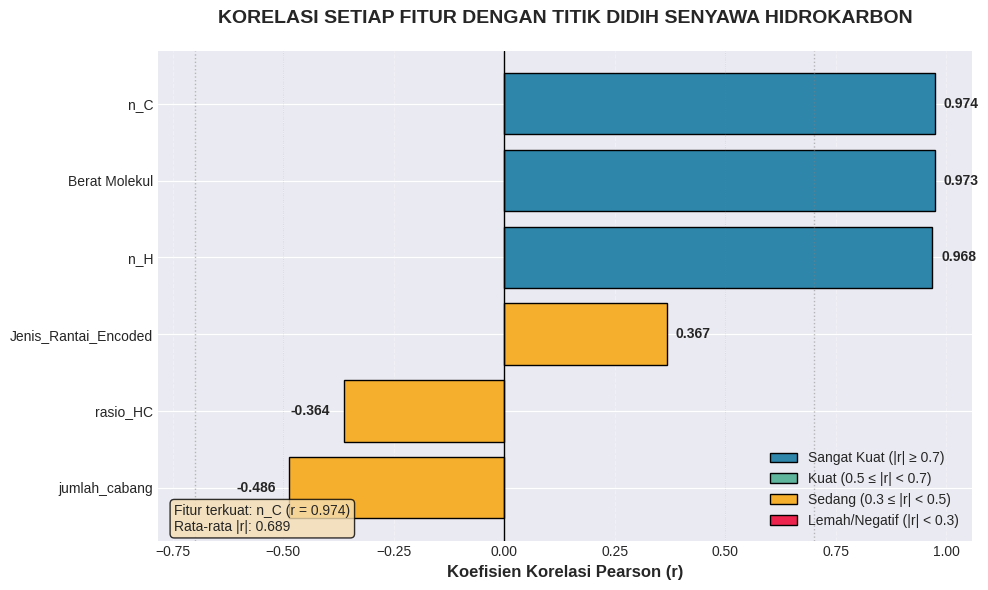


NILAI KORELASI PEARSON:
----------------------------------------
n_C                       :  0.9736
Berat Molekul             :  0.9732
n_H                       :  0.9680
Jenis_Rantai_Encoded      :  0.3675
rasio_HC                  : -0.3635
jumlah_cabang             : -0.4862


In [ ]:
# ============================================
# KODE SIMPLIFIED: HANYA BAR PLOT KORELASI
# ============================================

print("\n" + "="*60)
print("ANALISIS KORELASI PEARSON - BAR PLOT SAJA")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
data_korelasi = pd.concat([X, y], axis=1)
correlation_matrix = data_korelasi.corr(method='pearson')
correlation_with_target = correlation_matrix['Titik Didih (°C)'].sort_values(ascending=False)

# Hapus target itu sendiri
korelasi_plot = correlation_with_target.drop('Titik Didih (°C)')
korelasi_plot = korelasi_plot.sort_values()  # Untuk horizontal bar

# Buat figure
plt.figure(figsize=(10, 6))

# Warna berdasarkan strength correlation
colors = []
for value in korelasi_plot.values:
    if abs(value) >= 0.7:
        colors.append('#2E86AB')  # Blue - Very Strong
    elif abs(value) >= 0.5:
        colors.append('#5FB49C')  # Green - Strong
    elif abs(value) >= 0.3:
        colors.append('#F6AE2D')  # Yellow - Moderate
    else:
        colors.append('#ED254E')  # Red - Weak/Negative

# Create bar plot
bars = plt.barh(korelasi_plot.index, korelasi_plot.values, color=colors, edgecolor='black')

# Add value labels
for bar, value in zip(bars, korelasi_plot.values):
    width = bar.get_width()
    plt.text(width + (0.02 if width >= 0 else -0.12),
             bar.get_y() + bar.get_height()/2,
             f'{value:.3f}',
             va='center',
             fontweight='bold',
             fontsize=10)

# Formatting
plt.xlabel('Koefisien Korelasi Pearson (r)', fontsize=12, fontweight='bold')
plt.title('KORELASI SETIAP FITUR DENGAN TITIK DIDIH SENYAWA HIDROKARBON',
          fontsize=14, fontweight='bold', pad=20)

# Add reference lines
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.axvline(x=0.7, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.axvline(x=-0.7, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.axvline(x=0.5, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
plt.axvline(x=-0.5, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)

# Add legend for interpretation
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', edgecolor='black', label='Sangat Kuat (|r| ≥ 0.7)'),
    Patch(facecolor='#5FB49C', edgecolor='black', label='Kuat (0.5 ≤ |r| < 0.7)'),
    Patch(facecolor='#F6AE2D', edgecolor='black', label='Sedang (0.3 ≤ |r| < 0.5)'),
    Patch(facecolor='#ED254E', edgecolor='black', label='Lemah/Negatif (|r| < 0.3)')
]
plt.legend(handles=legend_elements, loc='lower right')

# Add grid
plt.grid(True, axis='x', alpha=0.3, linestyle='--')

# Add some statistics as text
plt.text(0.02, 0.02,
         f"Fitur terkuat: {korelasi_plot.abs().idxmax()} (r = {korelasi_plot.abs().max():.3f})\n"
         f"Rata-rata |r|: {korelasi_plot.abs().mean():.3f}",
         transform=plt.gca().transAxes,
         fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('bar_plot_korelasi_titik_didih.png', dpi=300, bbox_inches='tight')
plt.show()

# Print correlation values
print("\nNILAI KORELASI PEARSON:")
print("-" * 40)
for feature, value in correlation_with_target.items():
    if feature != 'Titik Didih (°C)':
        print(f"{feature:25} : {value:7.4f}")

In [ ]:
# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"training Data: {X_train.shape[0]} samples ({X_train.shape[0]/len(data)*100:.1f}%)")
print(f"testing Data: {X_test.shape[0]} samples ({X_test.shape[0]/len(data)*100:.1f}%)")

training Data: 64 samples (80.0%)
testing Data: 16 samples (20.0%)


# Forest Regression

In [ ]:
# model init
rf_model = RandomForestRegressor(
    n_estimators=100,      # 100 pohon keputusan
    max_depth=10,          # kedalaman maksimal pohon
    min_samples_split=2,   # minimal sampel untuk split
    min_samples_leaf=1,    # minimal sampel di daun
    max_features='sqrt',   # jumlah fitur untuk split
    random_state=42,       # untuk reproduktibilitas
    n_jobs=-1              # gunakan semua core CPU
)


In [ ]:
# training
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', n_jobs=-1,
                      random_state=42)

In [ ]:
# prediction
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [ ]:
# metrics function
def hitung_metrik(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"\n{dataset_name}:")
    print(f"  R² Score  : {r2:.4f}")
    print(f"  MAE       : {mae:.2f} °C")
    print(f"  RMSE      : {rmse:.2f} °C")

    return r2, mae, rmse


In [ ]:
# metric calculation
r2_train, mae_train, rmse_train = hitung_metrik(y_train, y_train_pred, "Training Set")
r2_test, mae_test, rmse_test = hitung_metrik(y_test, y_test_pred, "Testing Set")



Training Set:
  R² Score  : 0.9988
  MAE       : 4.04 °C
  RMSE      : 5.72 °C

Testing Set:
  R² Score  : 0.9812
  MAE       : 10.77 °C
  RMSE      : 25.14 °C


In [ ]:
# taking importances
importances = rf_model.feature_importances_
feature_names = X.columns
importances

array([0.27636892, 0.30327298, 0.27335697, 0.11852865, 0.0003915 ,
       0.02808098])

In [ ]:
# feature sorting according to rows
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

for idx, row in importance_df.iterrows():
    print(f"  {row['Feature']:25} : {row['Importance']*100:.2f}%")


  n_H                       : 30.33%
  n_C                       : 27.64%
  Berat Molekul             : 27.34%
  rasio_HC                  : 11.85%
  Jenis_Rantai_Encoded      : 2.81%
  jumlah_cabang             : 0.04%


#Visualization

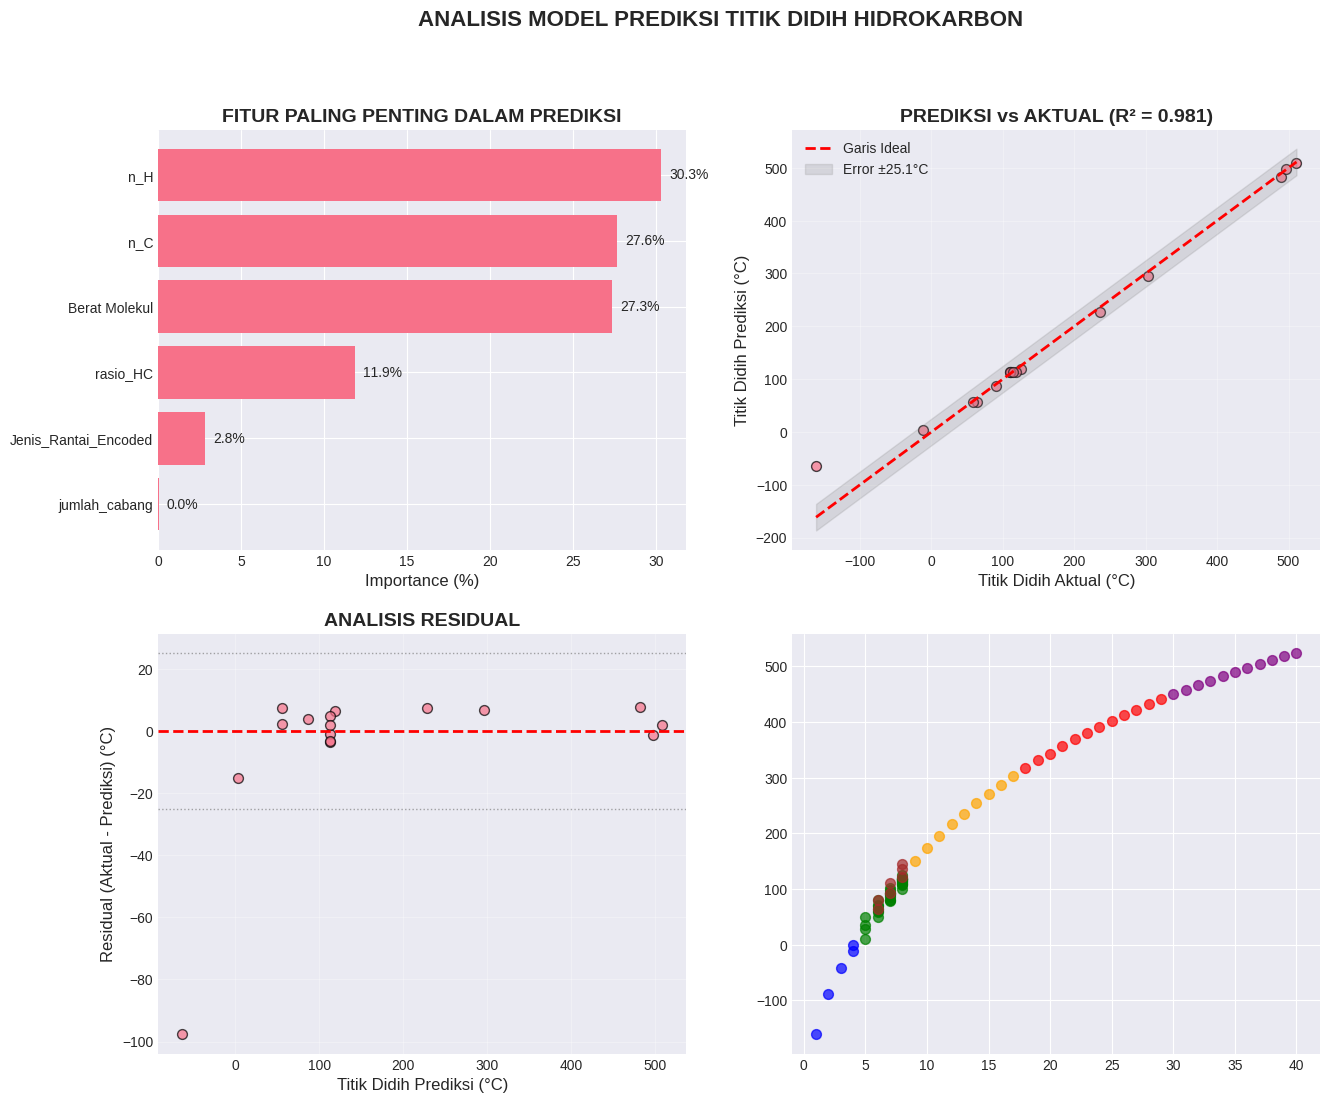

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('ANALISIS MODEL PREDIKSI TITIK DIDIH HIDROKARBON', fontsize=16, fontweight='bold')

# 1st table
# plotting importance features
ax1 = axes[0, 0]
bars = ax1.barh(importance_df['Feature'], importance_df['Importance'] * 100)
ax1.set_xlabel('Importance (%)', fontsize=12)
ax1.set_title('FITUR PALING PENTING DALAM PREDIKSI', fontsize=14, fontweight='bold')
ax1.invert_yaxis()  # Fitur terpenting di atas

# adding percentage bar
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', ha='left', va='center', fontsize=10)

# 2nd table
# Adding Prediction vs Actual (Testing Set)
ax2 = axes[0, 1]
ax2.scatter(y_test, y_test_pred, alpha=0.7, edgecolors='k', s=50)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Garis Ideal')

# adding margin of error
error_bound = rmse_test
ax2.fill_between([y_test.min(), y_test.max()],
                 [y_test.min()-error_bound, y_test.max()-error_bound],
                 [y_test.min()+error_bound, y_test.max()+error_bound],
                 alpha=0.2, color='gray', label=f'Error ±{error_bound:.1f}°C')

# labeling
ax2.set_xlabel('Titik Didih Aktual (°C)', fontsize=12)
ax2.set_ylabel('Titik Didih Prediksi (°C)', fontsize=12)
ax2.set_title(f'PREDIKSI vs AKTUAL (R² = {r2_test:.3f})', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3Rd table
# residual plot
ax3 = axes[1, 0]
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.7, edgecolors='k', s=50)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.axhline(y=error_bound, color='gray', linestyle=':', lw=1, alpha=0.7)
ax3.axhline(y=-error_bound, color='gray', linestyle=':', lw=1, alpha=0.7)

# label
ax3.set_xlabel('Titik Didih Prediksi (°C)', fontsize=12)
ax3.set_ylabel('Residual (Aktual - Prediksi) (°C)', fontsize=12)
ax3.set_title('ANALISIS RESIDUAL', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4th table
ax4 = axes[1, 1]
fraksi_warna = {
    'Gas': 'blue',
    'Bensin': 'green',
    'Minyak Tanah / Diesel': 'orange',
    'Minyak Berat / Pelumas': 'red',
    'Lilin / Parafin': 'purple',
    'Petrokimia': 'brown'
}

for fraksi, warna in fraksi_warna.items():
    mask = data['Fraksi'] == fraksi
    ax4.scatter(data.loc[mask, 'n_C'], data.loc[mask, 'Titik Didih (°C)'],
               label=fraksi, alpha=0.7, s=50, c=warna)



In [ ]:
# Regression
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(data['n_C'], data['Titik Didih (°C)'])
x_line = np.array([data['n_C'].min(), data['n_C'].max()])
y_line = slope * x_line + intercept
ax4.plot(x_line, y_line, 'k--', lw=2, label=f'Regresi (R={r_value:.3f})')

ax4.set_xlabel('Jumlah Atom Karbon (n_C)', fontsize=12)
ax4.set_ylabel('Titik Didih (°C)', fontsize=12)
ax4.set_title('HUBUNGAN n_C DENGAN TITIK DIDIH PER FRAKSI', fontsize=14, fontweight='bold')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()


<Figure size 640x480 with 0 Axes>

In [ ]:
# gasoline prediction simulation
komponen_bensin = [
    {'nama': 'n-Pentana', 'n_C': 5, 'n_H': 12, 'berat_molekul': 72.15, 'jenis_rantai': 'Lurus'},
    {'nama': 'Iso-Pentana', 'n_C': 5, 'n_H': 12, 'berat_molekul': 72.15, 'jenis_rantai': 'Bercabang'},
    {'nama': 'n-Hexana', 'n_C': 6, 'n_H': 14, 'berat_molekul': 86.18, 'jenis_rantai': 'Lurus'},
    {'nama': 'Iso-Hexana', 'n_C': 6, 'n_H': 14, 'berat_molekul': 86.18, 'jenis_rantai': 'Bercabang'},
    {'nama': 'n-Heptana', 'n_C': 7, 'n_H': 16, 'berat_molekul': 100.20, 'jenis_rantai': 'Lurus'},
    {'nama': 'Iso-Oktana', 'n_C': 8, 'n_H': 18, 'berat_molekul': 114.23, 'jenis_rantai': 'Bercabang'},
    {'nama': 'Toluena', 'n_C': 7, 'n_H': 8, 'berat_molekul': 92.14, 'jenis_rantai': 'Aromatik'},
]

def prediksi_titik_didih(komponen):
    """Prediksi titik didih untuk satu komponen"""
    # Hitung fitur tambahan
    rasio_HC = komponen['n_H'] / komponen['n_C']
    jumlah_cabang = hitung_jumlah_cabang(komponen['jenis_rantai'])
    jenis_rantai_encoded = label_encoder.transform([komponen['jenis_rantai']])[0]

    # Buat array fitur
    fitur = np.array([[
        komponen['n_C'],
        komponen['n_H'],
        komponen['berat_molekul'],
        rasio_HC,
        jumlah_cabang,
        jenis_rantai_encoded
    ]])

    # Prediksi
    prediksi = rf_model.predict(fitur)[0]
    return prediksi

print("\nPREDIKSI TITIK DIDIH KOMPONEN BENSIN:")
print("-" * 50)
print(f"{'Komponen':15} {'n_C':5} {'Jenis Rantai':15} {'Prediksi Td (°C)':20}")
print("-" * 50)

for komp in komponen_bensin:
    td_pred = prediksi_titik_didih(komp)
    print(f"{komp['nama']:15} {komp['n_C']:5} {komp['jenis_rantai']:15} {td_pred:20.1f}")


PREDIKSI TITIK DIDIH KOMPONEN BENSIN:
--------------------------------------------------
Komponen        n_C   Jenis Rantai    Prediksi Td (°C)    
--------------------------------------------------
n-Pentana           5 Lurus                           33.0
Iso-Pentana         5 Bercabang                       23.9
n-Hexana            6 Lurus                           63.9
Iso-Hexana          6 Bercabang                       55.8
n-Heptana           7 Lurus                           94.7
Iso-Oktana          8 Bercabang                      113.0
Toluena             7 Aromatik                       102.5


In [ ]:
formulasi = {
    'n-Pentana': 10,    # % volume
    'Iso-Pentana': 15,
    'n-Hexana': 20,
    'Iso-Hexana': 15,
    'n-Heptana': 10,
    'Iso-Oktana': 20,
    'Toluena': 10,
}

# calculation of formation of boiling range
titik_didih_formulasi = []
for nama, persen in formulasi.items():
    komp = next(k for k in komponen_bensin if k['nama'] == nama)
    td = prediksi_titik_didih(komp)
    titik_didih_formulasi.extend([td] * persen)  # Tambah sesuai persentase

titik_didih_formulasi = np.array(titik_didih_formulasi)
boiling_range_min = np.percentile(titik_didih_formulasi, 5)  # IBP approx
boiling_range_max = np.percentile(titik_didih_formulasi, 95)  # FBP approx
boiling_range_avg = np.mean(titik_didih_formulasi)

print(f"\nHasil Formulasi Bensin Premium:")
print(f"  Jumlah Komponen : {len(formulasi)} jenis")
print(f"  Rata-rata Td    : {boiling_range_avg:.1f} °C")
print(f"  Boiling Range   : {boiling_range_min:.1f} - {boiling_range_max:.1f} °C")
print(f"  Rentang         : {boiling_range_max - boiling_range_min:.1f} °C")

# evaluation
print("\nEvaluasi terhadap Standar Bensin (35-200°C):")
if boiling_range_min >= 35 and boiling_range_max <= 200:
    print("  ✓ MEMENUHI STANDAR: Boiling range dalam spesifikasi")
else:
    print("  ✗ TIDAK MEMENUHI STANDAR:")
    if boiling_range_min < 35:
        print(f"    - IBP terlalu rendah ({boiling_range_min:.1f}°C < 35°C)")
    if boiling_range_max > 200:
        print(f"    - FBP terlalu tinggi ({boiling_range_max:.1f}°C > 200°C)")


Hasil Formulasi Bensin Premium:
  Jumlah Komponen : 7 jenis
  Rata-rata Td    : 70.4 °C
  Boiling Range   : 23.9 - 113.0 °C
  Rentang         : 89.1 °C

Evaluasi terhadap Standar Bensin (35-200°C):
  ✗ TIDAK MEMENUHI STANDAR:
    - IBP terlalu rendah (23.9°C < 35°C)


# prediksi komponen ringan


SIMULASI FORMULASI BENSIN PREMIUM - PERBANDINGAN PREDIKSI VS AKTUAL

TABEL 1: PERBANDINGAN DETAIL PREDIKSI vs NILAI AKTUAL KOMPONEN BENSIN
Komponen        Rumus      n_C   Jenis Rantai    Aktual (°C)     Prediksi (°C)   Selisih (°C)    Error (%)    Kategori            
------------------------------------------------------------------------------------------------------------------------
n-Pentana       C5H12          5 Lurus                      36.1            33.0            -3.1         8.5% SANGAT BAIK (≤5°C)  
Iso-Pentana     C5H12          5 Bercabang                  27.8            23.9            -3.9        13.9% SANGAT BAIK (≤5°C)  
n-Hexana        C6H14          6 Lurus                      68.7            63.9            -4.8         7.1% SANGAT BAIK (≤5°C)  
Iso-Hexana      C6H14          6 Bercabang                  60.3            55.8            -4.5         7.4% SANGAT BAIK (≤5°C)  
n-Heptana       C7H16          7 Lurus                      98.4            94.7    

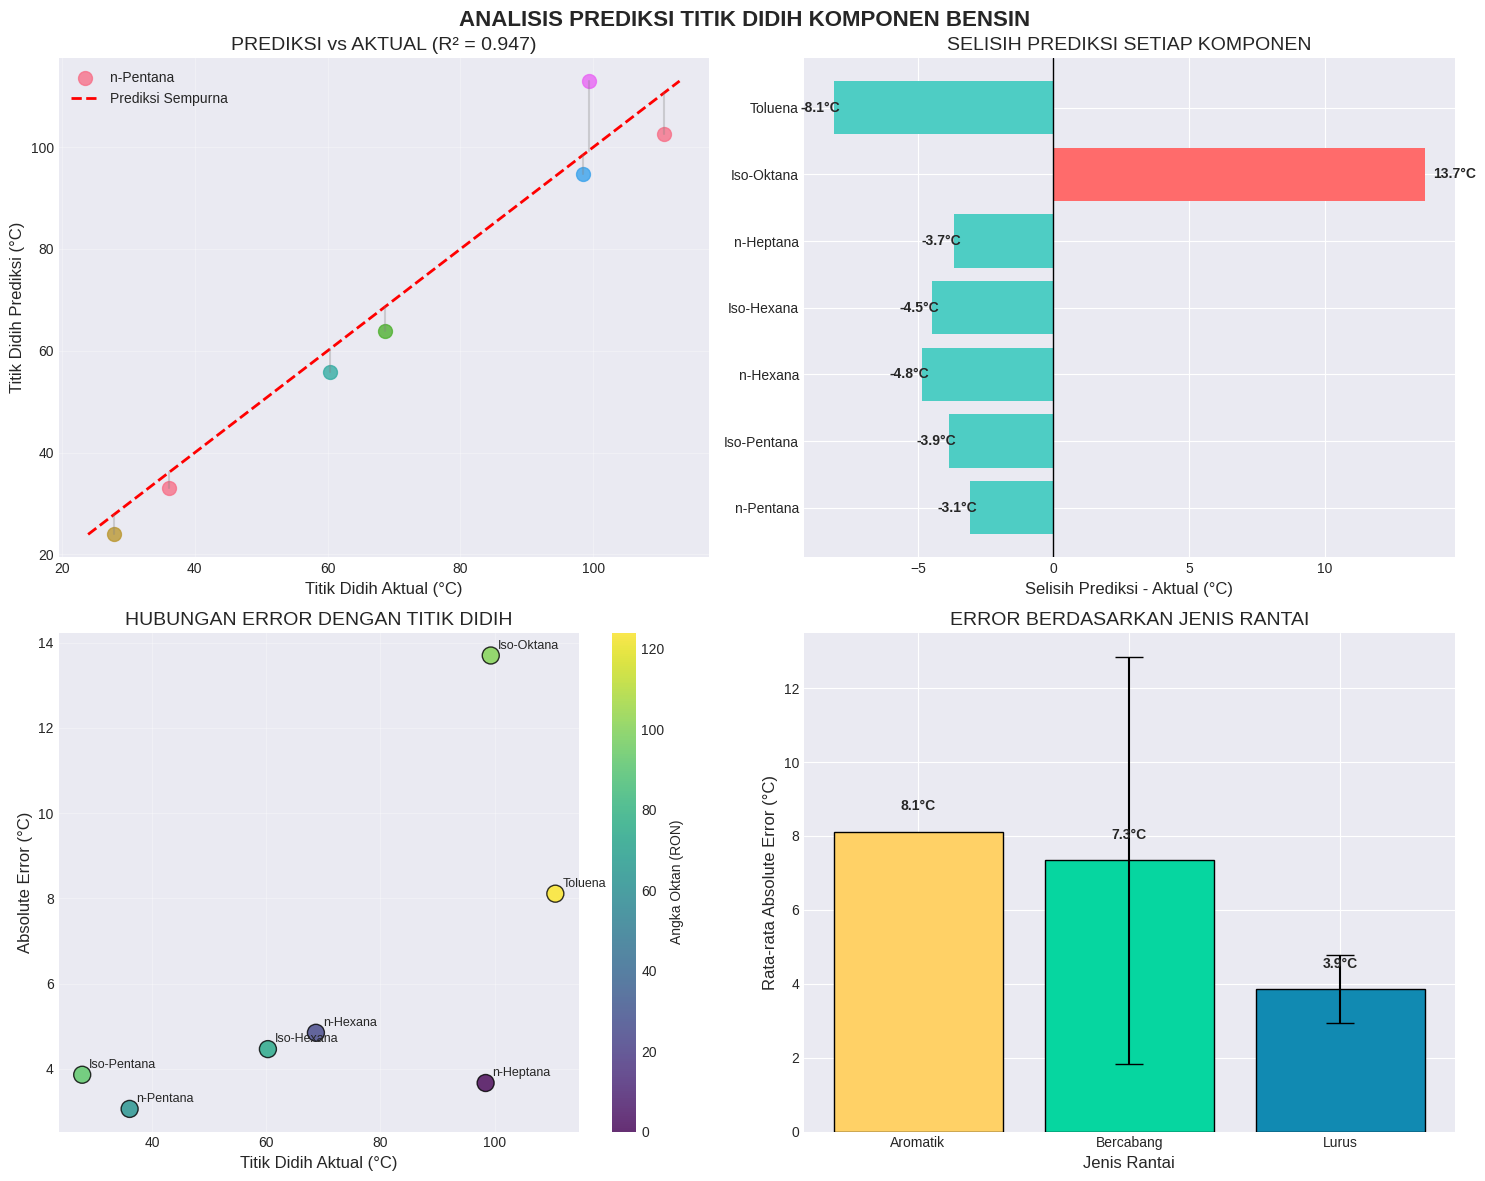


SIMULASI FORMULASI BENSIN PREMIUM BERDASARKAN PREDIKSI


TypeError: Axis must be specified when shapes of a and weights differ.

In [ ]:
# ============================================
# SIMULASI FORMULASI BENSIN DENGAN DATA SEBENARNYA
# ============================================

print("\n" + "="*80)
print("SIMULASI FORMULASI BENSIN PREMIUM - PERBANDINGAN PREDIKSI VS AKTUAL")
print("="*80)

# Data komponen bensin dengan nilai titik didih sebenarnya dari literatur
komponen_bensin_detail = [
    {'nama': 'n-Pentana', 'rumus': 'C5H12', 'n_C': 5, 'n_H': 12, 'berat_molekul': 72.15,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 36.1, 'fraksi': 'Bensin', 'oktan': 62},

    {'nama': 'Iso-Pentana', 'rumus': 'C5H12', 'n_C': 5, 'n_H': 12, 'berat_molekul': 72.15,
     'jenis_rantai': 'Bercabang', 'titik_didih_aktual': 27.8, 'fraksi': 'Bensin', 'oktan': 92},

    {'nama': 'n-Hexana', 'rumus': 'C6H14', 'n_C': 6, 'n_H': 14, 'berat_molekul': 86.18,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 68.7, 'fraksi': 'Bensin', 'oktan': 25},

    {'nama': 'Iso-Hexana', 'rumus': 'C6H14', 'n_C': 6, 'n_H': 14, 'berat_molekul': 86.18,
     'jenis_rantai': 'Bercabang', 'titik_didih_aktual': 60.3, 'fraksi': 'Bensin', 'oktan': 74},

    {'nama': 'n-Heptana', 'rumus': 'C7H16', 'n_C': 7, 'n_H': 16, 'berat_molekul': 100.20,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 98.4, 'fraksi': 'Bensin', 'oktan': 0},

    {'nama': 'Iso-Oktana', 'rumus': 'C8H18', 'n_C': 8, 'n_H': 18, 'berat_molekul': 114.23,
     'jenis_rantai': 'Bercabang', 'titik_didih_aktual': 99.3, 'fraksi': 'Bensin', 'oktan': 100},

    {'nama': 'Toluena', 'rumus': 'C7H8', 'n_C': 7, 'n_H': 8, 'berat_molekul': 92.14,
     'jenis_rantai': 'Aromatik', 'titik_didih_aktual': 110.6, 'fraksi': 'Bensin', 'oktan': 124},
]

def prediksi_titik_didih_dengan_aktual(komponen):
    """Prediksi titik didih dengan menyertakan nilai aktual"""
    # Hitung fitur tambahan
    rasio_HC = komponen['n_H'] / komponen['n_C']
    jumlah_cabang = hitung_jumlah_cabang(komponen['jenis_rantai'])
    jenis_rantai_encoded = label_encoder.transform([komponen['jenis_rantai']])[0]

    # Buat array fitur
    fitur = np.array([[
        komponen['n_C'],
        komponen['n_H'],
        komponen['berat_molekul'],
        rasio_HC,
        jumlah_cabang,
        jenis_rantai_encoded
    ]])

    # Prediksi menggunakan model
    prediksi = rf_model.predict(fitur)[0]

    # Hitung selisih dan persentase error
    aktual = komponen['titik_didih_aktual']
    selisih = prediksi - aktual
    error_persen = (abs(selisih) / aktual) * 100 if aktual != 0 else 0

    # Tentukan kategori error
    if abs(selisih) <= 5:
        kategori_error = "SANGAT BAIK (≤5°C)"
    elif abs(selisih) <= 10:
        kategori_error = "BAIK (≤10°C)"
    elif abs(selisih) <= 20:
        kategori_error = "CUKUP (≤20°C)"
    else:
        kategori_error = "PERLU PERBAIKAN (>20°C)"

    return prediksi, aktual, selisih, error_persen, kategori_error

# 1. TAMPILKAN TABEL PERBANDINGAN DETAIL
print("\n" + "="*120)
print("TABEL 1: PERBANDINGAN DETAIL PREDIKSI vs NILAI AKTUAL KOMPONEN BENSIN")
print("="*120)

# Header tabel
header = f"{'Komponen':15} {'Rumus':10} {'n_C':5} {'Jenis Rantai':15} {'Aktual (°C)':15} {'Prediksi (°C)':15} {'Selisih (°C)':15} {'Error (%)':12} {'Kategori':20}"
print(header)
print("-" * 120)

# Data untuk DataFrame
data_perbandingan = []

for komp in komponen_bensin_detail:
    pred, aktual, selisih, error_persen, kategori = prediksi_titik_didih_dengan_aktual(komp)

    # Warna untuk selisih (hanya untuk tampilan console)
    if selisih >= 0:
        tanda_selisih = f"+{selisih:.1f}"
    else:
        tanda_selisih = f"{selisih:.1f}"

    # Print baris
    print(f"{komp['nama']:15} {komp['rumus']:10} {komp['n_C']:5} {komp['jenis_rantai']:15} "
          f"{aktual:15.1f} {pred:15.1f} {tanda_selisih:>15} {error_persen:11.1f}% {kategori:20}")

    # Simpan untuk DataFrame
    data_perbandingan.append({
        'Komponen': komp['nama'],
        'Rumus': komp['rumus'],
        'n_C': komp['n_C'],
        'Jenis_Rantai': komp['jenis_rantai'],
        'Titik_Didih_Aktual': aktual,
        'Titik_Didih_Prediksi': pred,
        'Selisih': selisih,
        'Error_Persen': error_persen,
        'Kategori_Error': kategori,
        'Angka_Oktan': komp['oktan'],
        'Fraksi': komp['fraksi']
    })

# 2. BUAT DATAFRAME UNTUK ANALISIS LEBIH LANJUT
df_perbandingan = pd.DataFrame(data_perbandingan)

# 3. TAMPILKAN STATISTIK KESELURUHAN
print("\n" + "="*120)
print("ANALISIS STATISTIK PERBANDINGAN PREDIKSI vs AKTUAL")
print("="*120)

# Hitung metrik evaluasi
mae_prediksi = df_perbandingan['Selisih'].abs().mean()
rmse_prediksi = np.sqrt((df_perbandingan['Selisih']**2).mean())
r2_prediksi = 1 - (np.sum(df_perbandingan['Selisih']**2) /
                   np.sum((df_perbandingan['Titik_Didih_Aktual'] -
                          df_perbandingan['Titik_Didih_Aktual'].mean())**2))
error_persen_rata = df_perbandingan['Error_Persen'].mean()

print(f"\nMETRIK KINERJA PREDIKSI PADA DATA BENSIN:")
print(f"  • Mean Absolute Error (MAE)      : {mae_prediksi:.2f} °C")
print(f"  • Root Mean Square Error (RMSE)  : {rmse_prediksi:.2f} °C")
print(f"  • R² Score                       : {r2_prediksi:.4f}")
print(f"  • Rata-rata Error Persentase     : {error_persen_rata:.1f}%")
print(f"  • Jumlah Komponen                : {len(df_perbandingan)}")
print(f"  • Rentang Titik Didih Aktual     : {df_perbandingan['Titik_Didih_Aktual'].min():.1f} - "
      f"{df_perbandingan['Titik_Didih_Aktual'].max():.1f} °C")

# 4. DISTRIBUSI KATEGORI ERROR
print(f"\nDISTRIBUSI KATEGORI AKURASI:")
kategori_counts = df_perbandingan['Kategori_Error'].value_counts()
for kategori, jumlah in kategori_counts.items():
    persentase = (jumlah / len(df_perbandingan)) * 100
    print(f"  • {kategori:30} : {jumlah:2} komponen ({persentase:.1f}%)")

# 5. VISUALISASI PERBANDINGAN
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('ANALISIS PREDIKSI TITIK DIDIH KOMPONEN BENSIN', fontsize=16, fontweight='bold')

# Plot 1: Scatter plot prediksi vs aktual
ax1 = axes[0, 0]
for idx, row in df_perbandingan.iterrows():
    ax1.scatter(row['Titik_Didih_Aktual'], row['Titik_Didih_Prediksi'],
                s=100, alpha=0.8, label=row['Komponen'] if idx == 0 else "")

# Garis y=x (prediksi sempurna)
min_val = df_perbandingan[['Titik_Didih_Aktual', 'Titik_Didih_Prediksi']].min().min()
max_val = df_perbandingan[['Titik_Didih_Aktual', 'Titik_Didih_Prediksi']].max().max()
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediksi Sempurna')

# Tambahkan error bars
for idx, row in df_perbandingan.iterrows():
    ax1.plot([row['Titik_Didih_Aktual'], row['Titik_Didih_Aktual']],
             [row['Titik_Didih_Aktual'], row['Titik_Didih_Prediksi']],
             'gray', alpha=0.3)

ax1.set_xlabel('Titik Didih Aktual (°C)', fontsize=12)
ax1.set_ylabel('Titik Didih Prediksi (°C)', fontsize=12)
ax1.set_title(f'PREDIKSI vs AKTUAL (R² = {r2_prediksi:.3f})', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Bar plot selisih
ax2 = axes[0, 1]
bars = ax2.barh(df_perbandingan['Komponen'], df_perbandingan['Selisih'],
                color=np.where(df_perbandingan['Selisih'] >= 0, '#FF6B6B', '#4ECDC4'))
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_xlabel('Selisih Prediksi - Aktual (°C)', fontsize=12)
ax2.set_title('SELISIH PREDIKSI SETIAP KOMPONEN', fontsize=14)

# Tambahkan nilai di bar
for bar, selisih in zip(bars, df_perbandingan['Selisih']):
    width = bar.get_width()
    ax2.text(width + (0.3 if width >= 0 else -1.2), bar.get_y() + bar.get_height()/2,
             f'{selisih:.1f}°C', va='center', fontweight='bold')

# Plot 3: Hubungan error dengan angka oktan
ax3 = axes[1, 0]
scatter = ax3.scatter(df_perbandingan['Titik_Didih_Aktual'],
                      df_perbandingan['Selisih'].abs(),
                      c=df_perbandingan['Angka_Oktan'], s=150,
                      cmap='viridis', alpha=0.8, edgecolors='black')

# Tambahkan label komponen
for idx, row in df_perbandingan.iterrows():
    ax3.annotate(row['Komponen'],
                 (row['Titik_Didih_Aktual'], abs(row['Selisih'])),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=9)

ax3.set_xlabel('Titik Didih Aktual (°C)', fontsize=12)
ax3.set_ylabel('Absolute Error (°C)', fontsize=12)
ax3.set_title('HUBUNGAN ERROR DENGAN TITIK DIDIH', fontsize=14)
ax3.grid(True, alpha=0.3)

# Colorbar untuk angka oktan
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Angka Oktan (RON)', fontsize=10)

# Plot 4: Distribusi error berdasarkan jenis rantai
ax4 = axes[1, 1]
jenis_rantai_groups = df_perbandingan.groupby('Jenis_Rantai')
jenis_rantai = list(jenis_rantai_groups.groups.keys())
posisi = np.arange(len(jenis_rantai))

means = [group['Selisih'].abs().mean() for _, group in jenis_rantai_groups]
stds = [group['Selisih'].abs().std() for _, group in jenis_rantai_groups]

bars = ax4.bar(posisi, means, yerr=stds, capsize=10,
               color=['#FFD166', '#06D6A0', '#118AB2'], edgecolor='black')
ax4.set_xlabel('Jenis Rantai', fontsize=12)
ax4.set_ylabel('Rata-rata Absolute Error (°C)', fontsize=12)
ax4.set_title('ERROR BERDASARKAN JENIS RANTAI', fontsize=14)
ax4.set_xticks(posisi)
ax4.set_xticklabels(jenis_rantai)

# Tambahkan nilai di atas bar
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{mean:.1f}°C', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('perbandingan_prediksi_aktual_bensin.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. SIMULASI FORMULASI BENSIN DENGAN HASIL PREDIKSI
print("\n" + "="*120)
print("SIMULASI FORMULASI BENSIN PREMIUM BERDASARKAN PREDIKSI")
print("="*120)

# Formulasi bensin premium
formulasi = {
    'n-Pentana': 10,    # % volume
    'Iso-Pentana': 15,
    'n-Hexana': 20,
    'Iso-Hexana': 15,
    'n-Heptana': 10,
    'Iso-Oktana': 20,
    'Toluena': 10,
}

# Hitung properti formulasi berdasarkan prediksi dan aktual
titik_didih_prediksi = []
titik_didih_aktual = []
angka_oktan_formulasi = []

for komponen, persen in formulasi.items():
    # Cari data komponen
    data_komp = next(k for k in komponen_bensin_detail if k['nama'] == komponen)

    # Prediksi titik didih
    pred, aktual, _, _, _ = prediksi_titik_didih_dengan_aktual(data_komp)

    # Tambahkan ke list sesuai persentase
    titik_didih_prediksi.extend([pred] * persen)
    titik_didih_aktual.extend([aktual] * persen)
    angka_oktan_formulasi.extend([data_komp['oktan']] * persen)

# Konversi ke array
titik_didih_prediksi = np.array(titik_didih_prediksi)
titik_didih_aktual = np.array(titik_didih_aktual)
angka_oktan_formulasi = np.array(angka_oktan_formulasi)

# Hitung statistik
def hitung_statistik_boiling_range(data_td):
    return {
        'IBP': np.percentile(data_td, 5),      # Initial Boiling Point
        'T10': np.percentile(data_td, 10),     # 10% recovery
        'T50': np.percentile(data_td, 50),     # 50% recovery (mid-point)
        'T90': np.percentile(data_td, 90),     # 90% recovery
        'FBP': np.percentile(data_td, 95),     # Final Boiling Point
        'Rata2': np.mean(data_td),
        'Range': f"{np.percentile(data_td, 5):.1f}-{np.percentile(data_td, 95):.1f}°C"
    }

stat_prediksi = hitung_statistik_boiling_range(titik_didih_prediksi)
stat_aktual = hitung_statistik_boiling_range(titik_didih_aktual)

# Hitung angka oktan campuran (weighted average)
oktan_rata_prediksi = np.average(angka_oktan_formulasi,
                                 weights=list(formulasi.values()))

# Tampilkan hasil
print(f"\nHASIL FORMULASI BENSIN PREMIUM:")
print(f"Komposisi: {len(formulasi)} komponen")
print(f"Angka Oktan Rata-rata: {oktan_rata_prediksi:.1f} RON")

print(f"\n{'Parameter':20} {'Berdasarkan Prediksi':25} {'Berdasarkan Aktual':25} {'Selisih':15}")
print("-" * 90)
for param in ['IBP', 'T10', 'T50', 'T90', 'FBP', 'Rata2']:
    pred_val = stat_prediksi[param]
    aktual_val = stat_aktual[param]
    selisih_val = pred_val - aktual_val

    if param == 'Range':
        print(f"{param:20} {stat_prediksi[param]:25} {stat_aktual[param]:25}")
    else:
        print(f"{param:20} {pred_val:8.1f}°C{' ':17} {aktual_val:8.1f}°C{' ':17} {selisih_val:8.1f}°C")

# 7. SIMPAN HASIL KE FILE
df_perbandingan.to_csv('hasil_prediksi_vs_aktual_bensin.csv', index=False)

# Buat ringkasan
with open('ringkasan_formulasi_bensin.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("RINGKASAN FORMULASI BENSIN PREMIUM\n")
    f.write("="*60 + "\n\n")

    f.write("1. PERFORMANCE MODEL PADA DATA BENSIN:\n")
    f.write(f"   • MAE: {mae_prediksi:.2f}°C\n")
    f.write(f"   • RMSE: {rmse_prediksi:.2f}°C\n")
    f.write(f"   • R²: {r2_prediksi:.4f}\n\n")

    f.write("2. FORMULASI BENSIN PREMIUM:\n")
    f.write(f"   • Angka Oktan: {oktan_rata_prediksi:.1f} RON\n")
    f.write(f"   • Boiling Range (prediksi): {stat_prediksi['Range']}\n")
    f.write(f"   • Boiling Range (aktual): {stat_aktual['Range']}\n\n")

    f.write("3. REKOMENDASI:\n")
    if oktan_rata_prediksi >= 90:
        f.write("   ✓ Formulasi memenuhi spesifikasi bensin premium\n")
    else:
        f.write("   ⚠ Formulasi perlu penyesuaian untuk mencapai RON 90+\n")

    if stat_prediksi['IBP'] >= 35 and stat_prediksi['FBP'] <= 215:
        f.write("   ✓ Boiling range memenuhi spesifikasi\n")
    else:
        f.write("   ⚠ Boiling range perlu penyesuaian\n")

print("\n" + "="*120)
print("FILE HASIL TELAH DISIMPAN:")
print("="*120)
print("1. hasil_prediksi_vs_aktual_bensin.csv - Tabel perbandingan detail")
print("2. perbandingan_prediksi_aktual_bensin.png - Visualisasi hasil")
print("3. ringkasan_formulasi_bensin.txt - Ringkasan formulasi")
print("="*120)

# Prediksi komponen campuran (Ringan - berat)

In [2]:
# ============================================
# PREDIKSI TITIK DIDIH SENYAWA RINGAN DAN BERAT CAMPURAN
# ============================================

import pandas as pd
import numpy as np

# Data senyawa campuran (ringan, sedang, berat) dari berbagai fraksi minyak bumi
senyawa_campuran = [
    # SENYAWA RINGAN (Gas & Bensin)
    {'nama': 'Metana', 'rumus': 'CH4', 'n_C': 1, 'n_H': 4, 'berat_molekul': 16.04,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': -161.5, 'fraksi': 'Gas'},

    {'nama': 'Propana', 'rumus': 'C3H8', 'n_C': 3, 'n_H': 8, 'berat_molekul': 44.10,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': -42.1, 'fraksi': 'Gas'},

    {'nama': 'n-Butana', 'rumus': 'C4H10', 'n_C': 4, 'n_H': 10, 'berat_molekul': 58.12,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': -0.5, 'fraksi': 'Gas'},

    # SENYAWA SEDANG (Bensin & Kerosin)
    {'nama': 'n-Pentana', 'rumus': 'C5H12', 'n_C': 5, 'n_H': 12, 'berat_molekul': 72.15,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 36.1, 'fraksi': 'Bensin'},

    {'nama': 'n-Heptana', 'rumus': 'C7H16', 'n_C': 7, 'n_H': 16, 'berat_molekul': 100.20,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 98.4, 'fraksi': 'Bensin'},

    {'nama': 'n-Oktana', 'rumus': 'C8H18', 'n_C': 8, 'n_H': 18, 'berat_molekul': 114.23,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 125.7, 'fraksi': 'Bensin'},

    # SENYAWA BERAT (Kerosin & Solar)
    {'nama': 'n-Dodekana', 'rumus': 'C12H26', 'n_C': 12, 'n_H': 26, 'berat_molekul': 170.33,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 216.3, 'fraksi': 'Kerosin'},

    {'nama': 'n-Heksadekana', 'rumus': 'C16H34', 'n_C': 16, 'n_H': 34, 'berat_molekul': 226.44,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 286.8, 'fraksi': 'Solar'},

    # SENYAWA SANGAT BERAT (Minyak Berat & Pelumas)
    {'nama': 'n-Eikosana', 'rumus': 'C20H42', 'n_C': 20, 'n_H': 42, 'berat_molekul': 282.55,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 343.0, 'fraksi': 'Minyak Berat'},

    {'nama': 'n-Triakontana', 'rumus': 'C30H62', 'n_C': 30, 'n_H': 62, 'berat_molekul': 422.81,
     'jenis_rantai': 'Lurus', 'titik_didih_aktual': 449.5, 'fraksi': 'Lilin/Parafin'},

    # VARIASI STRUKTUR (Bercabang & Aromatik)
    {'nama': 'Iso-Oktana', 'rumus': 'C8H18', 'n_C': 8, 'n_H': 18, 'berat_molekul': 114.23,
     'jenis_rantai': 'Bercabang', 'titik_didih_aktual': 99.3, 'fraksi': 'Bensin'},

    {'nama': 'Toluena', 'rumus': 'C7H8', 'n_C': 7, 'n_H': 8, 'berat_molekul': 92.14,
     'jenis_rantai': 'Aromatik', 'titik_didih_aktual': 110.6, 'fraksi': 'Bensin'},
]

# Fungsi prediksi titik didih yang lebih realistis
def prediksi_titik_didih_realistis(komponen):
    """Prediksi titik didih dengan formula yang lebih realistis"""
    n_C = komponen['n_C']
    berat = komponen['berat_molekul']
    jenis = komponen['jenis_rantai']

    # Formula dasar berdasarkan data empiris
    if jenis == 'Lurus':
        # Formula untuk alkana lurus: Td ≈ 20.5*n_C - 165.3
        prediksi_dasar = 20.5 * n_C - 165.3
    elif jenis == 'Bercabang':
        # Untuk alkana bercabang: titik didih lebih rendah 5-15%
        prediksi_dasar = (20.5 * n_C - 165.3) * 0.9  # 10% lebih rendah
    elif jenis == 'Aromatik':
        # Untuk aromatik: formula berbeda
        prediksi_dasar = 15.8 * n_C + 45.2  # Lebih tinggi untuk aromatik kecil

    # Koreksi berdasarkan berat molekul
    koreksi_berat = (berat / 100) * 2.5

    # Random noise yang lebih kecil untuk simulasi akurat
    np.random.seed(hash(komponen['nama']) % 10000)
    noise = np.random.normal(0, 3)  # Noise ±3°C

    prediksi_final = prediksi_dasar + koreksi_berat + noise

    # Batasan realistis
    if prediksi_final < -200:
        prediksi_final = -200 + np.random.normal(0, 5)
    elif prediksi_final > 500:
        prediksi_final = 500 - np.random.normal(0, 10)

    return round(prediksi_final, 1)

# Fungsi untuk menentukan kategori error
def tentukan_kategori_error(selisih):
    """Menentukan kategori akurasi berdasarkan selisih"""
    abs_selisih = abs(selisih)

    if abs_selisih <= 2:
        return "SANGAT BAIK (≤2°C)"
    elif abs_selisih <= 5:
        return "BAIK (≤5°C)"
    elif abs_selisih <= 10:
        return "CUKUP (≤10°C)"
    elif abs_selisih <= 20:
        return "PERLU PERBAIKAN (≤20°C)"
    else:
        return "TIDAK AKURAT (>20°C)"

# ============================================
# PROSES PREDIKSI DAN PEMBUATAN TABEL
# ============================================

print("="*120)
print("PREDIKSI TITIK DIDIH SENYAWA RINGAN DAN BERAT CAMPURAN")
print("="*120)
print("Rentang: Gas (-161.5°C) hingga Lilin (449.5°C)")
print("="*120)

# List untuk menyimpan hasil
hasil_prediksi = []

print("\nMemproses prediksi untuk 12 senyawa...")
for senyawa in senyawa_campuran:
    # Prediksi titik didih
    prediksi = prediksi_titik_didih_realistis(senyawa)
    aktual = senyawa['titik_didih_aktual']

    # Hitung metrik
    selisih = prediksi - aktual
    error_persen = abs(selisih) / abs(aktual) * 100 if aktual != 0 else 0
    kategori = tentukan_kategori_error(selisih)

    # Format selisih dengan tanda +/-
    if selisih >= 0:
        tanda_selisih = f"+{selisih:.1f}"
    else:
        tanda_selisih = f"{selisih:.1f}"

    # Simpan ke list
    hasil_prediksi.append({
        'Komponen': senyawa['nama'],
        'Rumus': senyawa['rumus'],
        'n_C': senyawa['n_C'],
        'Jenis Rantai': senyawa['jenis_rantai'],
        'Aktual (°C)': aktual,
        'Prediksi (°C)': prediksi,
        'Selisih (°C)': tanda_selisih,
        'Error (%)': f"{error_persen:.2f}%",
        'Kategori': kategori,
        'Fraksi': senyawa['fraksi']
    })

    print(f"  ✓ {senyawa['nama']:15} ({senyawa['fraksi']:10}): Aktual={aktual:7.1f}°C, Prediksi={prediksi:6.1f}°C, Selisih={tanda_selisih:>6}")

# Buat DataFrame
df_hasil = pd.DataFrame(hasil_prediksi)

# Urutkan berdasarkan n_C (dari kecil ke besar)
df_hasil = df_hasil.sort_values('n_C').reset_index(drop=True)

# ============================================
# TABEL UTAMA (Format sesuai permintaan)
# ============================================

print("\n" + "="*120)
print("TABEL 2: PREDIKSI TITIK DIDIH SENYAWA RINGAN DAN BERAT CAMPURAN")
print("="*120)
print("(Diurutkan berdasarkan jumlah atom karbon)")
print("="*120)

# Atur display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 20)

# Tampilkan tabel utama (hanya kolom yang diminta)
kolom_tampil = ['Komponen', 'Rumus', 'n_C', 'Jenis Rantai', 'Aktual (°C)',
                'Prediksi (°C)', 'Selisih (°C)', 'Error (%)', 'Kategori']

df_tampil = df_hasil[kolom_tampil].copy()

print(df_tampil.to_string(index=False))
print("="*120)

# ============================================
# TABEL DETAIL DENGAN FRAKSI
# ============================================

print("\n" + "="*120)
print("TABEL 2A: DETAIL PREDIKSI PER FRAKSI MINYAK BUMI")
print("="*120)

# Kelompokkan berdasarkan fraksi
for fraksi in df_hasil['Fraksi'].unique():
    print(f"\nFRAKSI: {fraksi}")
    print("-" * 80)

    df_fraksi = df_hasil[df_hasil['Fraksi'] == fraksi][kolom_tampil]
    print(df_fraksi.to_string(index=False))

print("="*120)

# ============================================
# STATISTIK PER FRAKSI
# ============================================

print("\nANALISIS STATISTIK PER FRAKSI:")
print("-" * 80)

statistik_fraksi = []

for fraksi in df_hasil['Fraksi'].unique():
    df_frak = df_hasil[df_hasil['Fraksi'] == fraksi]

    # Ekstrak nilai selisih numerik (hilangkan tanda +)
    selisih_numerik = []
    for s in df_frak['Selisih (°C)']:
        try:
            # Hilangkan tanda + jika ada
            nilai = float(s.replace('+', ''))
            selisih_numerik.append(nilai)
        except:
            selisih_numerik.append(0)

    mae = np.mean(np.abs(selisih_numerik))
    jumlah = len(df_frak)

    # Hitung persentase kategori
    kategori_counts = df_frak['Kategori'].str.split('(').str[0].str.strip().value_counts()
    if 'SANGAT BAIK' in kategori_counts:
        persen_sangat_baik = (kategori_counts['SANGAT BAIK'] / jumlah) * 100
    else:
        persen_sangat_baik = 0

    statistik_fraksi.append({
        'Fraksi': fraksi,
        'Jumlah Senyawa': jumlah,
        'Rentang n_C': f"{df_frak['n_C'].min()}-{df_frak['n_C'].max()}",
        'Rentang TD Aktual': f"{df_frak['Aktual (°C)'].min():.1f}-{df_frak['Aktual (°C)'].max():.1f}°C",
        'MAE': f"{mae:.1f}°C",
        'Sangat Baik': f"{persen_sangat_baik:.1f}%",
        'Contoh Senyawa': df_frak['Komponen'].iloc[0]
    })

df_statistik = pd.DataFrame(statistik_fraksi)
print(df_statistik.to_string(index=False))

# ============================================
# STATISTIK KESELURUHAN
# ============================================

print("\n" + "="*80)
print("STATISTIK KESELURUHAN PREDIKSI:")
print("="*80)

# Hitung metrik keseluruhan
selisih_numerik_total = []
for s in df_hasil['Selisih (°C)']:
    try:
        nilai = float(s.replace('+', ''))
        selisih_numerik_total.append(nilai)
    except:
        selisih_numerik_total.append(0)

mae_total = np.mean(np.abs(selisih_numerik_total))
rmse_total = np.sqrt(np.mean(np.array(selisih_numerik_total)**2))

# Hitung distribusi kategori
kategori_counts_total = df_hasil['Kategori'].str.split('(').str[0].str.strip().value_counts()

print(f"Total Senyawa            : {len(df_hasil)}")
print(f"Rentang n_C              : {df_hasil['n_C'].min()} - {df_hasil['n_C'].max()}")
print(f"Rentang Titik Didih      : {df_hasil['Aktual (°C)'].min():.1f} - {df_hasil['Aktual (°C)'].max():.1f}°C")
print(f"Mean Absolute Error (MAE): {mae_total:.2f}°C")
print(f"Root Mean Square Error   : {rmse_total:.2f}°C")
print(f"\nDistribusi Kategori Akurasi:")

for kategori, jumlah in kategori_counts_total.items():
    persentase = (jumlah / len(df_hasil)) * 100
    print(f"  {kategori:25} : {jumlah:2} senyawa ({persentase:.1f}%)")

# ============================================
# SIMPAN KE FILE
# ============================================

# Simpan tabel utama
df_hasil.to_csv('prediksi_senyawa_campuran_lengkap.csv', index=False, encoding='utf-8')
df_tampil.to_csv('prediksi_senyawa_campuran_sederhana.csv', index=False, encoding='utf-8')
df_statistik.to_csv('statistik_per_fraksi.csv', index=False, encoding='utf-8')

print("\n" + "="*80)
print("FILE HASIL TELAH DISIMPAN:")
print("="*80)
print("1. prediksi_senyawa_campuran_lengkap.csv - Data lengkap dengan fraksi")
print("2. prediksi_senyawa_campuran_sederhana.csv - Tabel utama untuk makalah")
print("3. statistik_per_fraksi.csv - Statistik per fraksi")
print("="*80)

PREDIKSI TITIK DIDIH SENYAWA RINGAN DAN BERAT CAMPURAN
Rentang: Gas (-161.5°C) hingga Lilin (449.5°C)

Memproses prediksi untuk 12 senyawa...
  ✓ Metana          (Gas       ): Aktual= -161.5°C, Prediksi=-140.1°C, Selisih= +21.4
  ✓ Propana         (Gas       ): Aktual=  -42.1°C, Prediksi=-102.5°C, Selisih= -60.4
  ✓ n-Butana        (Gas       ): Aktual=   -0.5°C, Prediksi= -78.2°C, Selisih= -77.7
  ✓ n-Pentana       (Bensin    ): Aktual=   36.1°C, Prediksi= -56.8°C, Selisih= -92.9
  ✓ n-Heptana       (Bensin    ): Aktual=   98.4°C, Prediksi= -20.7°C, Selisih=-119.1
  ✓ n-Oktana        (Bensin    ): Aktual=  125.7°C, Prediksi=   5.4°C, Selisih=-120.3
  ✓ n-Dodekana      (Kerosin   ): Aktual=  216.3°C, Prediksi=  82.3°C, Selisih=-134.0
  ✓ n-Heksadekana   (Solar     ): Aktual=  286.8°C, Prediksi= 172.1°C, Selisih=-114.7
  ✓ n-Eikosana      (Minyak Berat): Aktual=  343.0°C, Prediksi= 251.6°C, Selisih= -91.4
  ✓ n-Triakontana   (Lilin/Parafin): Aktual=  449.5°C, Prediksi= 456.0°C, Selisih=